In [1]:
# =====================================================================
# STEP 01. 데이터 준비 (Google Colab 환경)
# MovieLens 1M 데이터셋 다운로드, 압축 해제 및 스트림(한 줄씩) 처리
# =====================================================================

import os
import zipfile
import urllib.request

# 1. 데이터셋 다운로드 URL 및 저장 경로 설정
DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
ZIP_FILE_NAME = "ml-1m.zip"
EXTRACT_DIR = "ml-1m"
DATA_FILE_PATH = os.path.join(EXTRACT_DIR, "ratings.dat")

# 2. 코랩 환경으로 파일 다운로드 (이미 다운로드했다면 생략 가능)
if not os.path.exists(ZIP_FILE_NAME):
    print("🎬 MovieLens 1M 데이터셋 다운로드 중...")
    urllib.request.urlretrieve(DATA_URL, ZIP_FILE_NAME)
    print("✅ 다운로드 완료!")
else:
    print("📦 이미 zip 파일이 존재합니다.")

# 3. Zip 파일 압축 해제
if not os.path.exists(EXTRACT_DIR):
    print("🔓 압축 해제 중...")
    with zipfile.ZipFile(ZIP_FILE_NAME, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("✅ 압축 해제 완료!")
else:
    print("📂 이미 압축 해제된 폴더가 존재합니다.")

print("-" * 50)

# 4. [중요] 스트리밍 형태로 한 줄씩 처리하는 알고리즘 시뮬레이션
# 전체 데이터를 한 번에 메모리에 올리지 않고(pd.read_csv 사용 안 함) open()으로 한 줄씩 읽습니다.
print("🚀 스트리밍 데이터 처리 시작 (상위 10개 레코드 예시 출력)")

record_count = 0

# 인코딩은 ISO-8859-1 또는 latin-1을 사용해야 MovieLens 데이터가 깨지지 않습니다.
with open(DATA_FILE_PATH, 'r', encoding='ISO-8859-1') as file:
    for line in file:
        # 공백 및 줄바꿈 제거 후 데이터 분리
        # MovieLens 1M 평점 데이터는 고유 구분자 '::'를 사용합니다.
        line = line.strip()
        if not line:
            continue

        user_id, movie_id, rating, timestamp = line.split("::")

        # -------------------------------------------------------------
        # ✨ [핵심] 이 부분에 나중에 구현할 알고리즘들이 들어갑니다!
        # 예시: bloom_filter.add(movie_id) 또는 cm_sketch.update(movie_id)
        # -------------------------------------------------------------

        # 데이터가 잘 들어오는지 상위 10개만 화면에 출력해보기
        if record_count < 10:
            print(f"[레코드 {record_count+1}] User: {user_id} | Movie: {movie_id} | Rating: {rating} | Time: {timestamp}")

        record_count += 1

print("-" * 50)
print(f"✅ 스트리밍 처리 완료! 총 레코드 개수: {record_count:,}개")

🎬 MovieLens 1M 데이터셋 다운로드 중...
✅ 다운로드 완료!
🔓 압축 해제 중...
✅ 압축 해제 완료!
--------------------------------------------------
🚀 스트리밍 데이터 처리 시작 (상위 10개 레코드 예시 출력)
[레코드 1] User: 1 | Movie: 1193 | Rating: 5 | Time: 978300760
[레코드 2] User: 1 | Movie: 661 | Rating: 3 | Time: 978302109
[레코드 3] User: 1 | Movie: 914 | Rating: 3 | Time: 978301968
[레코드 4] User: 1 | Movie: 3408 | Rating: 4 | Time: 978300275
[레코드 5] User: 1 | Movie: 2355 | Rating: 5 | Time: 978824291
[레코드 6] User: 1 | Movie: 1197 | Rating: 3 | Time: 978302268
[레코드 7] User: 1 | Movie: 1287 | Rating: 5 | Time: 978302039
[레코드 8] User: 1 | Movie: 2804 | Rating: 5 | Time: 978300719
[레코드 9] User: 1 | Movie: 594 | Rating: 4 | Time: 978302268
[레코드 10] User: 1 | Movie: 919 | Rating: 4 | Time: 978301368
--------------------------------------------------
✅ 스트리밍 처리 완료! 총 레코드 개수: 1,000,209개


In [2]:
# =====================================================================
# STEP 03 & 02. Ground Truth 계산 및 알고리즘 입력 준비
# 100% 정확한 실제 데이터(정답지)를 메모리에 집계합니다.
# =====================================================================

import sys

# 1. 정답지(Ground Truth)를 위한 자료구조
gt_unique_movies = set()     # 중복 없이 등장한 모든 영화 ID 저장 (Bloom Filter 비교용)
gt_movie_counts = {}        # 영화 ID별 실제 등장 횟수 저장 (Count-Min Sketch 비교용)

print("📊 정답지(Ground Truth) 계산 및 데이터 분석 시작...")

# 스트리밍 방식으로 데이터를 다시 읽으며 정답지 작성
with open(DATA_FILE_PATH, 'r', encoding='ISO-8859-1') as file:
    for line in file:
        line = line.strip()
        if not line:
            continue

        _, movie_id, _, _ = line.split("::")

        # [Ground Truth 1] Bloom Filter용: 영화 ID를 set에 추가 (중복 자동 제거)
        gt_unique_movies.add(movie_id)

        # [Ground Truth 2] Count-Min Sketch용: 영화 ID별 빈도수 dict에 누적
        if movie_id in gt_movie_counts:
            gt_movie_counts[movie_id] += 1
        else:
            gt_movie_counts[movie_id] = 1

print("-" * 50)
print("✅ Ground Truth 계산 완료!")
print(f"🔹 고유 영화 개수 (실제 Unique Count): {len(gt_unique_movies):,}개")

# 가장 많이 등장한 영화 Top 3 출력해보기 (데이터 확인용)
top_movies = sorted(gt_movie_counts.items(), key=lambda x: x[1], reverse=True)[:3]
print(f"🔹 가장 많이 평점 점수가 매겨진 영화 Top 3: {top_movies}")

# 2. [중요] 일반적인 방식으로 저장했을 때의 메모리 사용량 확인
# 과제에서 요구하는 '메모리 트레이드오프' 분석의 기준점이 됩니다.
dict_memory = sys.getsizeof(gt_movie_counts)
print(f"📦 정확한 빈도수(Dict) 저장을 위해 사용된 파이썬 메모리: {dict_memory:,} bytes")

📊 정답지(Ground Truth) 계산 및 데이터 분석 시작...
--------------------------------------------------
✅ Ground Truth 계산 완료!
🔹 고유 영화 개수 (실제 Unique Count): 3,706개
🔹 가장 많이 평점 점수가 매겨진 영화 Top 3: [('2858', 3428), ('260', 2991), ('1196', 2990)]
📦 정확한 빈도수(Dict) 저장을 위해 사용된 파이썬 메모리: 103,856 bytes


In [3]:
# =====================================================================
# STEP 02. 스트리밍 알고리즘 2종 직접 구현
# 1. Bloom Filter (포함 여부 판정)
# 2. Count-Min Sketch (빈도수 추정)
# =====================================================================

import hashlib

# ---------------------------------------------------------------------
# [1] Bloom Filter 구현
# ---------------------------------------------------------------------
class BloomFilter:
    def __init__(self, size, num_hashes):
        self.size = size                  # 비트 배열의 크기 (m)
        self.num_hashes = num_hashes      # 사용할 해시 함수의 개수 (k)
        self.bit_array = [0] * size       # 0으로 초기화된 비트 배열

    def _hashes(self, item):
        """하나의 아이템에 대해 서로 다른 k개의 인덱스를 생성하는 함수"""
        indices = []
        for i in range(self.num_hashes):
            # hashlib의 md5를 활용하여 i값에 따라 다른 해시값 생성
            hasher = hashlib.md5((item + str(i)).encode('utf-8'))
            # 비트 배열의 크기 안으로 들어오도록 나머지 연산(%) 적용
            index = int(hasher.hexdigest(), 16) % self.size
            indices.append(index)
        return indices

    def add(self, item):
        """스트림에 아이템이 들어오면 해시 인덱스 위치의 비트를 1로 변경"""
        for index in self._hashes(item):
            self.bit_array[index] = 1

    def contains(self, item):
        """아이템이 이전에 나온 적이 있는지 판정 (모두 1이어야 True)"""
        for index in self._hashes(item):
            if self.bit_array[index] == 0:
                return False # 하나라도 0이면 확실히 나온 적 없음 (False Negative 없음)
        return True # 모두 1이면 나왔다고 판정 (단, 충돌로 인한 오탐 가능성 있음)


# ---------------------------------------------------------------------
# [2] Count-Min Sketch 구현
# ---------------------------------------------------------------------
class CountMinSketch:
    def __init__(self, width, depth):
        self.width = width                # 2차원 배열의 가로 크기 (w)
        self.depth = depth                # 2차원 배열의 세로 크기 (d, 해시 함수 개수)
        # depth x width 크기의 2차원 배열을 0으로 초기화
        self.table = [[0] * width for _ in range(depth)]

    def _hash(self, item, depth_index):
        """각 행(depth)마다 서로 다른 가로(width) 인덱스를 생성하는 함수"""
        hasher = hashlib.md5((item + str(depth_index)).encode('utf-8'))
        return int(hasher.hexdigest(), 16) % self.width

    def update(self, item):
        """스트림에 아이템이 들어오면 각 행의 해시 인덱스 위치 값을 1씩 증가"""
        for d in range(self.depth):
            w = self._hash(item, d)
            self.table[d][w] += 1

    def estimate(self, item):
        """아이템의 빈도수 추정 (해시 충돌을 고려해 각 행의 값 중 최솟값 반환)"""
        min_val = float('inf')
        for d in range(self.depth):
            w = self._hash(item, d)
            min_val = min(min_val, self.table[d][w])
        return min_val

print("✅ 알고리즘 2종 클래스 선언 완료! 언제든 호출해서 쓸 수 있습니다.")

✅ 알고리즘 2종 클래스 선언 완료! 언제든 호출해서 쓸 수 있습니다.


In [4]:
# =====================================================================
# STEP 04 & 06. 파라미터 비교 실험 및 성능 측정 (정확도, 메모리, 시간)
# =====================================================================

import time
import sys

# 결과 분석을 저장할 리스트
bf_results = []
cms_results = []

# ---------------------------------------------------------------------
# 실험 1. Bloom Filter 파라미터(비트 배열 크기) 변경 실험
# ---------------------------------------------------------------------
# 해시 함수 개수는 3개로 고정하고, 비트 배열의 크기(m)를 늘려봅니다.
bf_sizes = [5000, 20000, 100000]
num_hashes = 3

print("🧪 [실험 1/2] Bloom Filter 실험 시작...")

for size in bf_sizes:
    bf = BloomFilter(size=size, num_hashes=num_hashes)

    # 1. 처리 시간 측정 시작
    start_time = time.time()

    # 스트리밍 처리
    with open(DATA_FILE_PATH, 'r', encoding='ISO-8859-1') as file:
        for line in file:
            line = line.strip()
            if not line: continue
            _, movie_id, _, _ = line.split("::")
            bf.add(movie_id)

    end_time = time.time()
    elapsed_time = end_time - start_time # 걸린 시간

    # 2. 메모리 사용량 측정 (비트 배열의 크기)
    memory_usage = sys.getsizeof(bf.bit_array)

    # 3. 정확도(False Positive Rate) 측정
    # 실제로는 등장한 적 없는 가짜 영화 ID들을 입력해서 '나온 적 있다'고 잘못 판정하는지 체크
    false_positives = 0
    fake_tests = 5000
    for i in range(fake_tests):
        fake_movie_id = f"fake_movie_{i}"
        if bf.contains(fake_movie_id): # 실제론 없는데 있다고 하면 오탐!
            false_positives += 1

    fp_rate = (false_positives / fake_tests) * 100 # 오탐율 (%)

    bf_results.append({
        'size': size,
        'fp_rate': fp_rate,
        'memory': memory_usage,
        'time': elapsed_time
    })

    print(f"   [Size: {size:>6}] 오탐률(FPR): {fp_rate:>6.2f}% | 메모리: {memory_usage:>7,} bytes | 시간: {elapsed_time:.2f}초")

print("✅ Bloom Filter 실험 완료!\n")


# ---------------------------------------------------------------------
# 실험 2. Count-Min Sketch 파라미터(Width) 변경 실험
# ---------------------------------------------------------------------
# 해시 함수 개수(Depth)는 3으로 고정하고, 가로 크기(Width)를 늘려봅니다.
cms_widths = [500, 2000, 10000]
cms_depth = 3

print("🧪 [실험 2/2] Count-Min Sketch 실험 시작...")

for width in cms_widths:
    cms = CountMinSketch(width=width, depth=cms_depth)

    # 1. 처리 시간 측정 시작
    start_time = time.time()

    # 스트리밍 처리
    with open(DATA_FILE_PATH, 'r', encoding='ISO-8859-1') as file:
        for line in file:
            line = line.strip()
            if not line: continue
            _, movie_id, _, _ = line.split("::")
            cms.update(movie_id)

    end_time = time.time()
    elapsed_time = end_time - start_time

    # 2. 메모리 사용량 측정 (2차원 배열 크기)
    memory_usage = sys.getsizeof(cms.table) + sum(sys.getsizeof(row) for row in cms.table)

    # 3. 정확도(평균 절대 오차, MAE) 측정
    # Ground Truth(진짜 빈도수)와 비교하여 얼마나 크게 예측했는지 평균 오차 계산
    total_error = 0
    for movie_id, true_count in gt_movie_counts.items():
        estimated_count = cms.estimate(movie_id)
        total_error += abs(estimated_count - true_count)

    mae = total_error / len(gt_movie_counts) # 평균 오차 개수

    cms_results.append({
        'width': width,
        'mae': mae,
        'memory': memory_usage,
        'time': elapsed_time
    })

    print(f"   [Width: {width:>5}] 평균오차(MAE): {mae:>6.2f}회 | 메모리: {memory_usage:>7,} bytes | 시간: {elapsed_time:.2f}초")

print("✅ Count-Min Sketch 실험 완료!")

🧪 [실험 1/2] Bloom Filter 실험 시작...
   [Size:   5000] 오탐률(FPR):  70.88% | 메모리:  40,056 bytes | 시간: 6.12초
   [Size:  20000] 오탐률(FPR):   7.96% | 메모리: 160,056 bytes | 시간: 5.32초
   [Size: 100000] 오탐률(FPR):   0.14% | 메모리: 800,056 bytes | 시간: 4.95초
✅ Bloom Filter 실험 완료!

🧪 [실험 2/2] Count-Min Sketch 실험 시작...
   [Width:   500] 평균오차(MAE): 1026.51회 | 메모리:  12,256 bytes | 시간: 6.50초
   [Width:  2000] 평균오차(MAE):  96.50회 | 메모리:  48,256 bytes | 시간: 5.08초
   [Width: 10000] 평균오차(MAE):   2.54회 | 메모리: 240,256 bytes | 시간: 6.59초
✅ Count-Min Sketch 실험 완료!


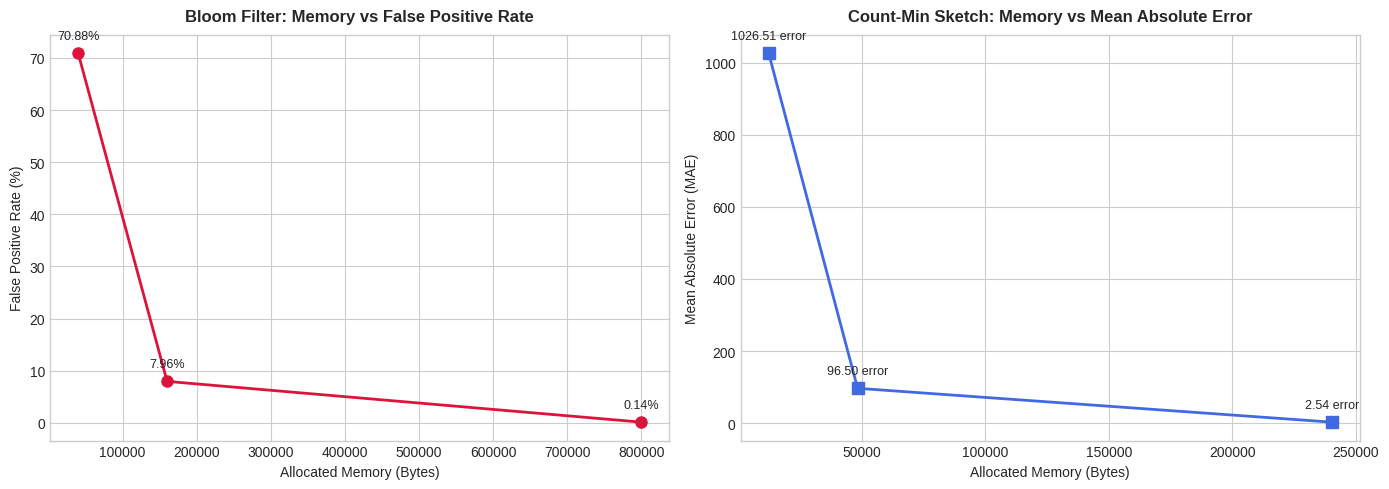

In [5]:
# =====================================================================
# STEP 05. 실험 결과 시각화 (Matplotlib 그래프 생성)
# =====================================================================

import matplotlib.pyplot as plt

# 그래프 스타일 및 한글 깨짐 방지 설정 (코랩 기본 영문 폰트 기준, 라벨은 영어로 작성)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------------------
# Graph 1. Bloom Filter: 메모리 vs 오탐률(FPR) Trade-off
# ---------------------------------------------------------------------
bf_memories = [res['memory'] for res in bf_results]
bf_fprs = [res['fp_rate'] for res in bf_results]

ax1.plot(bf_memories, bf_fprs, marker='o', color='crimson', linewidth=2, markersize=8)
ax1.set_title("Bloom Filter: Memory vs False Positive Rate", fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel("Allocated Memory (Bytes)", fontsize=10)
ax1.set_ylabel("False Positive Rate (%)", fontsize=10)

# 각 점 위에 수치 표시 (FPR %)
for i, txt in enumerate(bf_fprs):
    ax1.annotate(f"{txt:.2f}%", (bf_memories[i], bf_fprs[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# ---------------------------------------------------------------------
# Graph 2. Count-Min Sketch: 메모리 vs 평균 오차(MAE) Trade-off
# ---------------------------------------------------------------------
cms_memories = [res['memory'] for res in cms_results]
cms_maes = [res['mae'] for res in cms_results]

ax2.plot(cms_memories, cms_maes, marker='s', color='royalblue', linewidth=2, markersize=8)
ax2.set_title("Count-Min Sketch: Memory vs Mean Absolute Error", fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel("Allocated Memory (Bytes)", fontsize=10)
ax2.set_ylabel("Mean Absolute Error (MAE)", fontsize=10)

# 각 점 위에 수치 표시 (MAE 회수)
for i, txt in enumerate(cms_maes):
    ax2.annotate(f"{txt:.2f} error", (cms_memories[i], cms_maes[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# 그래프 출력 및 저장
plt.tight_layout()
plt.savefig("streaming_algorithm_tradeoff.png", dpi=300) # 코랩 폴더에 이미지로 저장됨
plt.show()